For Fig. S2A-G

In [2]:
suppressPackageStartupMessages({
library(tidyverse)
library(ggplot2)
library(showtext)
library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


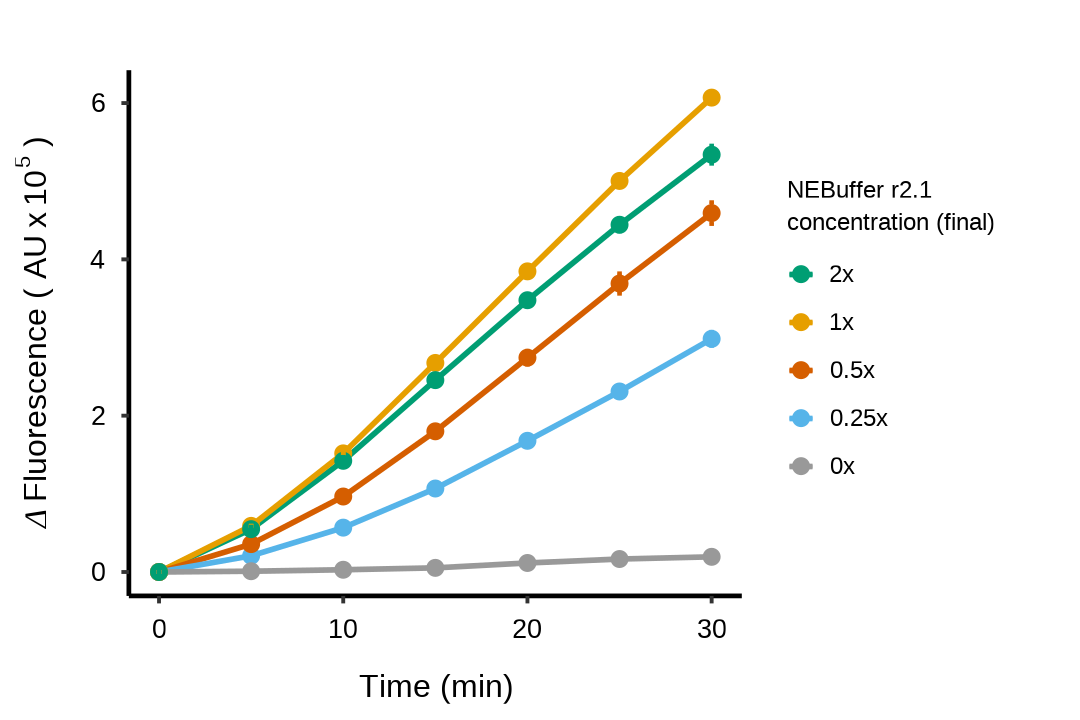

In [3]:
#buffer concentration - Fig. S2A
WD <- "~data/"

T47D <- read.csv(paste0(WD, "buffer_conc_T47D.csv"), header = TRUE, row.names = 1, check.names = FALSE)

#devide by 10^5
T47D <- T47D / 10^5

#plot
options(repr.plot.width = 9, repr.plot.height =6) 
df <- T47D
colnames(df) <- make.unique(colnames(df), sep = "__rep")

df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(-time, names_to = "condition_raw", values_to = "value") %>%
  mutate(
    # replicate number if present at the end after dots (".1" or "...1"), else 0
    rep_num = str_extract(condition_raw, "(?<=\\.)\\d+$"),
    rep_num = if_else(is.na(rep_num), 0L, as.integer(rep_num)),
    replicate = rep_num + 1L,  # 0 -> 1, 1 -> 2, 2 -> 3
    condition = str_remove(condition_raw, "__rep\\d+$"),
    time = as.numeric(time)
  ) %>%
  select(-rep_num)

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

df_summary$condition <- factor(
  df_summary$condition,
levels = c("2x", "1x", "0.5x", "0.25x", "0x")
)

#specify
colours <- c(
  "0x" = "#999999",
  "0.25x" = "#56B4E9",
  "0.5x" = "#D55E00",
  "1x" = "#E69F00",
  "2x" = "#009E73"
)

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = "NEBuffer r2.1 \nconcentration (final)") +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "right",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"buffer_conc_T47D.pdf"), plot = last_plot(), width = 9, height = 6, units = "in")

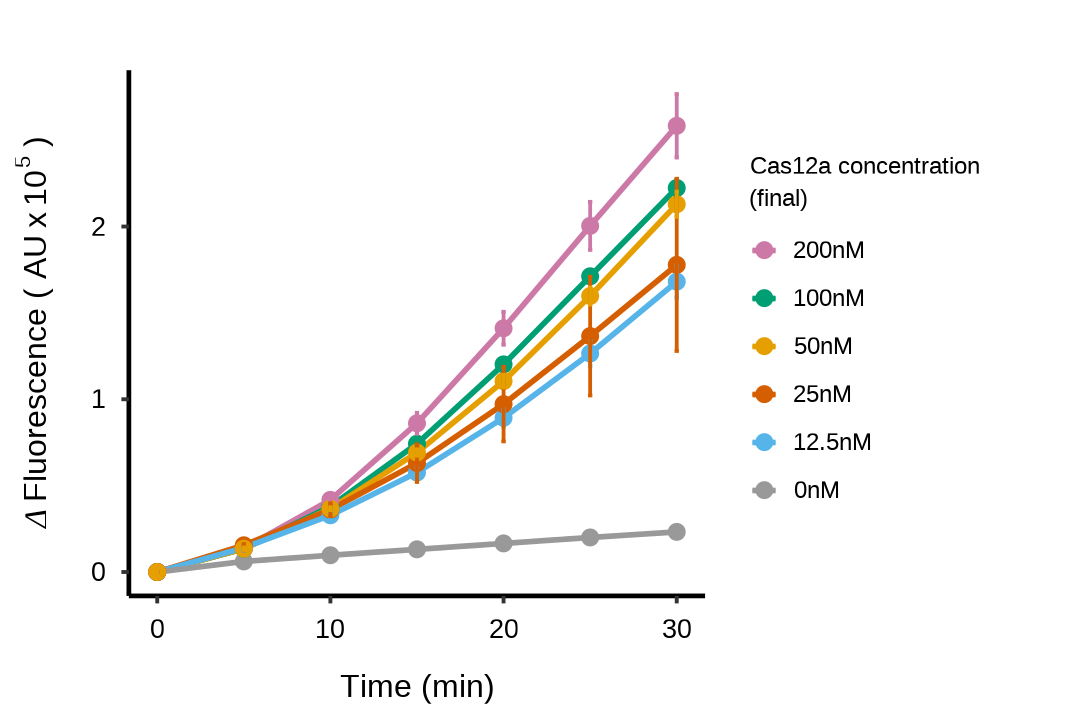

In [4]:
#Cas12a concentration - Fig. S2B
T47D <- read.csv(paste0(WD, "Cas12a_conc_T47D.csv"), header = TRUE, row.names = 1, check.names = FALSE)

#devide by 10^5
T47D <- T47D / 10^5

#plot
options(repr.plot.width = 9, repr.plot.height =6) 
df <- T47D
colnames(df) <- make.unique(colnames(df), sep = "__rep")

df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(-time, names_to = "condition_raw", values_to = "value") %>%
  mutate(
    # replicate number if present at the end after dots (".1" or "...1"), else 0
    rep_num = str_extract(condition_raw, "(?<=\\.)\\d+$"),
    rep_num = if_else(is.na(rep_num), 0L, as.integer(rep_num)),
    replicate = rep_num + 1L,  # 0 -> 1, 1 -> 2, 2 -> 3
    condition = str_remove(condition_raw, "__rep\\d+$"),
    time = as.numeric(time)
  ) %>%
  select(-rep_num)

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

df_summary$condition <- factor(
  df_summary$condition,
levels = c("200nM", "100nM", "50nM", "25nM", "12.5nM", "0nM")
)

#specify
colours <- c(
  "0nM" = "#999999",
  "12.5nM" = "#56B4E9",
  "25nM" = "#D55E00",
  "50nM" = "#E69F00",
  "100nM" = "#009E73",
  "200nM" = "#CC79A7"
)

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = "Cas12a concentration \n(final)") +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "right",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"Cas12a_conc_T47D.pdf"), plot = last_plot(), width = 9, height = 6, units = "in")

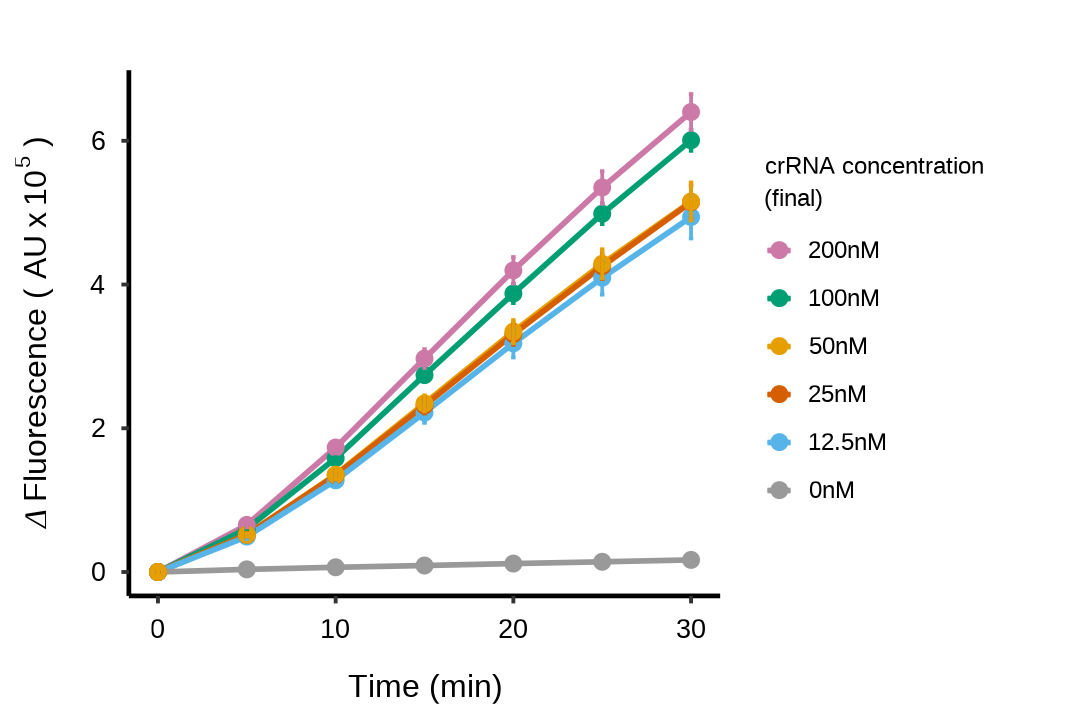

In [5]:
#crRNA concentration - Fig. S2C
T47D <- read.csv(paste0(WD, "crRNA_conc_T47D.csv"), header = TRUE, row.names = 1, check.names = FALSE)

#devide by 10^5
T47D <- T47D / 10^5

#plot
options(repr.plot.width = 9, repr.plot.height =6) 
df <- T47D
colnames(df) <- make.unique(colnames(df), sep = ".")

df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(-time, names_to = "condition_raw", values_to = "value") %>%
  mutate(
    # replicate number if present at the end after dots (".1" or "...1"), else 0
    rep_num = str_extract(condition_raw, "(?<=\\.)\\d+$"),
    rep_num = if_else(is.na(rep_num), 0L, as.integer(rep_num)),
    replicate = rep_num + 1L,  # 0 -> 1, 1 -> 2, 2 -> 3
    condition = str_remove(condition_raw, "\\.+\\d+$"),  # remove trailing .1 / ...1 etc
    time = as.numeric(time)
  ) %>%
  select(-rep_num)

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

df_summary$condition <- factor(
  df_summary$condition,
  levels = c("200nM",  "100nM", "50nM", "25nM", "12.5nM", "0nM" )
)

#specify
colours <- c(
  "0nM" = "#999999",
  "12.5nM" = "#56B4E9",
  "25nM" = "#D55E00",
  "50nM" = "#E69F00",
  "100nM" = "#009E73",
  "200nM" = "#CC79A7"
)

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = "crRNA concentration \n(final)") +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "right",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )

#save
ggsave(paste0(WD,"crRNA_conc_T47D.pdf"), plot = last_plot(), width = 9, height = 6, units = "in")

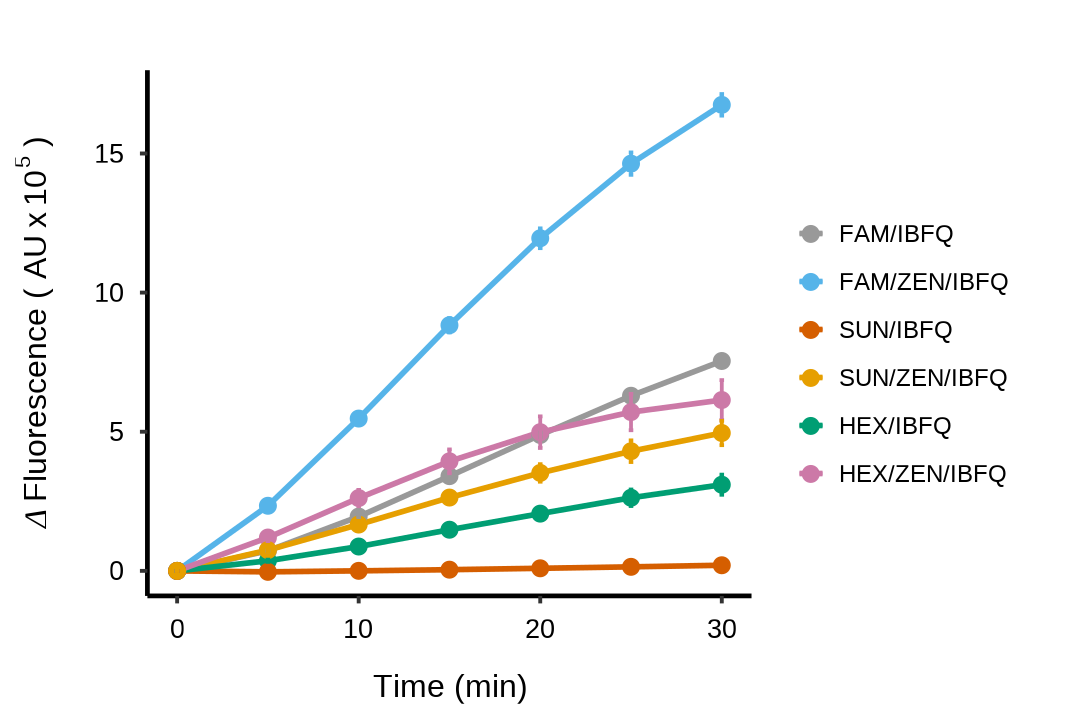

In [6]:
#different probes - Fig. S2D
T47D <- read.csv(paste0(WD, "probe_T47D.csv"), header = TRUE, row.names = 1, check.names = FALSE)

#devide by 10^5
T47D <- T47D / 10^5

#plot
options(repr.plot.width = 9, repr.plot.height =6) 
df <- T47D
colnames(df) <- make.unique(colnames(df), sep = "__rep")

df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(-time, names_to = "condition_raw", values_to = "value") %>%
  mutate(
    # replicate number if present at the end after dots (".1" or "...1"), else 0
    rep_num = str_extract(condition_raw, "(?<=\\.)\\d+$"),
    rep_num = if_else(is.na(rep_num), 0L, as.integer(rep_num)),
    replicate = rep_num + 1L,  # 0 -> 1, 1 -> 2, 2 -> 3
    condition = str_remove(condition_raw, "__rep\\d+$"),
    time = as.numeric(time)
  ) %>%
  select(-rep_num)

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

df_summary$condition <- factor(
  df_summary$condition,
levels = c("FAM/IBFQ", "FAM/ZEN/IBFQ", "SUN/IBFQ", "SUN/ZEN/IBFQ", "HEX/IBFQ", "HEX/ZEN/IBFQ")
)

#specify
colours <- c(
  "FAM/IBFQ" = "#999999",
  "FAM/ZEN/IBFQ" = "#56B4E9",
  "SUN/IBFQ" = "#D55E00",
  "SUN/ZEN/IBFQ" = "#E69F00",
  "HEX/IBFQ" = "#009E73",
  "HEX/ZEN/IBFQ" = "#CC79A7"
)

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = "") +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "right",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"probe_T47D.pdf"), plot = last_plot(), width = 9, height = 6, units = "in")

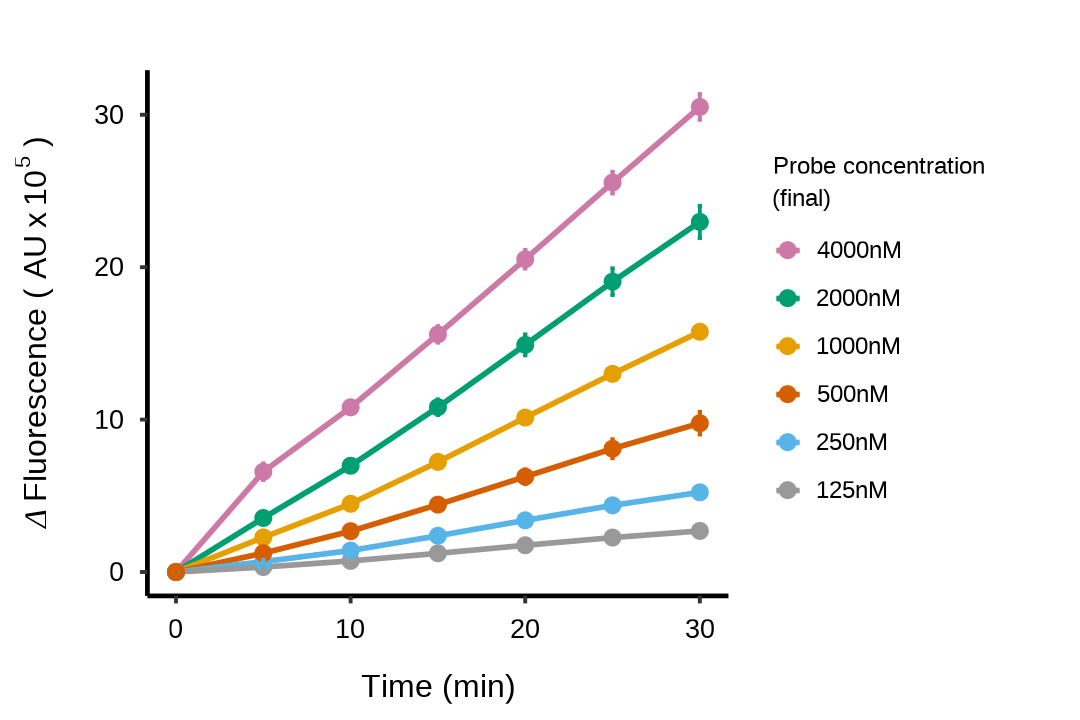

In [7]:
#probe (FAM/ZEN/IBFQ) concentration - Fig. S2E
T47D <- read.csv(paste0(WD, "probe_conc_T47D.csv"), header = TRUE, row.names = 1, check.names = FALSE)

#devide by 10^5
T47D <- T47D / 10^5

#plot
options(repr.plot.width = 9, repr.plot.height =6) 
df <- T47D
colnames(df) <- make.unique(colnames(df), sep = "__rep")

df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(-time, names_to = "condition_raw", values_to = "value") %>%
  mutate(
    # replicate number if present at the end after dots (".1" or "...1"), else 0
    rep_num = str_extract(condition_raw, "(?<=\\.)\\d+$"),
    rep_num = if_else(is.na(rep_num), 0L, as.integer(rep_num)),
    replicate = rep_num + 1L,  # 0 -> 1, 1 -> 2, 2 -> 3
    condition = str_remove(condition_raw, "__rep\\d+$"),
    time = as.numeric(time)
  ) %>%
  select(-rep_num)

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

df_summary$condition <- factor(
  df_summary$condition,
levels = c("4000nM", "2000nM", "1000nM", "500nM", "250nM", "125nM")
)

#specify
colours <- c(
  "125nM" = "#999999",
  "250nM" = "#56B4E9",
  "500nM" = "#D55E00",
  "1000nM" = "#E69F00",
  "2000nM" = "#009E73",
  "4000nM" = "#CC79A7"
)

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = "Probe concentration \n(final)") +
  labs( title = "",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = "right",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"probe_conc_T47D.pdf"), plot = last_plot(), width = 9, height = 6, units = "in")

In [8]:
#different crRNAs - Fig. S2G
U2OS <- read.csv(paste0(WD, "crRNAs_U2OS.csv"), header = TRUE, row.names = 1)
colnames(U2OS) <- sub("^no\\.crRNA", "no crRNA", colnames(U2OS))

T47D <- read.csv(paste0(WD, "crRNAs_T47D.csv"), header = TRUE, row.names = 1)
colnames(T47D) <- sub("^no\\.crRNA", "no crRNA", colnames(T47D))

#devide by 10^5

U2OS <- U2OS / 10^5
T47D <- T47D / 10^5

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


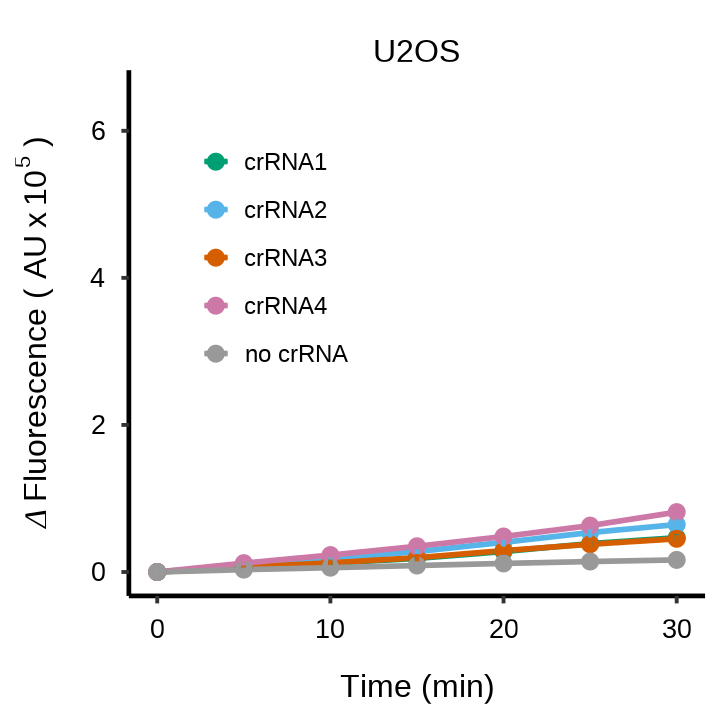

In [9]:
#plot U2OS
options(repr.plot.width = 6, repr.plot.height =6) 
df <- U2OS

# Reshape into long format
df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#specify
colours <- c("crRNA1" = "#009E73",
             "crRNA2" = "#56B4E9",
             "crRNA3" = "#D55E00",
             "crRNA4" = "#CC79A7",
             "no crRNA" = "#999999"
            )

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(0, 6.5) +
  labs( title = "U2OS",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = c(0.1, 0.9),   # move legend inside
    legend.justification = c("left", "top"),
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"comparison_crRNAs_U2OS.pdf"), plot = last_plot(), width = 6, height = 6, units = "in")

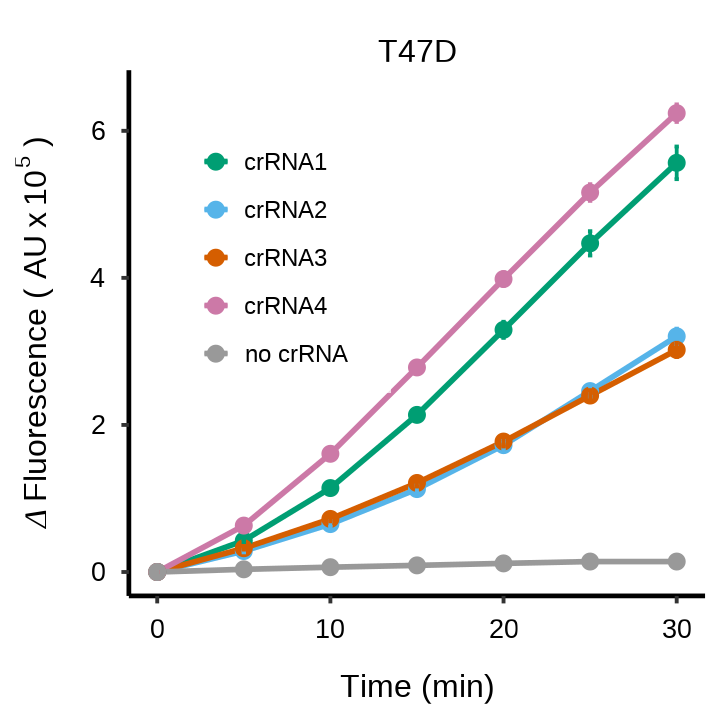

In [10]:
#plot T47D
options(repr.plot.width = 6, repr.plot.height =6) 
df <- T47D

# Reshape into long format
df_long <- df %>%
  rownames_to_column("time") %>%
  pivot_longer(
    cols = -time,                # exclude 'time' from pivoting
    names_to = "condition_raw",
    values_to = "value"
  ) %>%
  separate(condition_raw, into = c("condition", "replicate"), sep = "\\.", fill = "right") %>%
  mutate(
    replicate = ifelse(is.na(replicate), 1, as.numeric(replicate) + 1),  # crRNA1 -> rep1, .1 -> rep2, .2 -> rep3
    time = as.numeric(time)                                             # convert time back to numeric
  )

df_summary <- df_long %>%
  group_by(time, condition) %>%
  summarise(mean = mean(value), sd = sd(value), .groups = "drop")

#specify
colours <- c("crRNA1" = "#009E73",
             "crRNA2" = "#56B4E9",
             "crRNA3" = "#D55E00",
             "crRNA4" = "#CC79A7",
             "no crRNA" = "#999999"
            )

ggplot(df_summary, aes(x = time, y = mean, color = condition)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), width = 0.25, size = 0.8) +
  scale_color_manual(values = colours, name = NULL) +
  ylim(0, 6.5) +
  labs( title = "T47D",
    x = "Time (min)",
  ) +
  ylab((expression(Delta * " Fluorescence ( AU " * x~10^5 * " )")))+
  theme_bw(base_size = 18) +
  theme(
    axis.title.x = element_text(size = 24, margin = margin(t = 15), color = "black"),  
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),  
    axis.text = element_text(size = 20, color = "black"),
    axis.text.x = element_text(vjust = 1, hjust = 0.5,margin = margin(t = 10)), #vjust controls vertical justification (up/down) and hjust controls horizontal justification (left/right)
    axis.text.y = element_text(vjust = 0.5, hjust = 1,margin = margin(r = 10)),
    legend.position = c(0.1, 0.9),   # move legend inside
    legend.justification = c("left", "top"),
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.text = element_text(size = 18, color = "black"),
    legend.key.height = unit(2, "lines"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    plot.title = element_text(
    hjust = 0.5,   # center
    size = 24,     # increase size (adjust as needed)
    color = "black",
    margin = margin(t = 15)
  )
  )
#save
ggsave(paste0(WD,"comparison_crRNAs_T47D.pdf"), plot = last_plot(), width = 6, height = 6, units = "in")

In [11]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7  showtextdb_3.0  sysfonts_0.8.9  lubridate_1.9.4
 [5] forcats_1.0.0   stringr_1.5.2   dplyr_1.1.4     purrr_1.1.0    
 [9] readr_2.1.5     tidyr_1.3.1     tibble_3.3.0    ggplot2_3.5.2  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0  